# Notebook 03 - Corpus Analysis & Feature Extraction

## Environment Setup and Library Imports

This section initializes the working environment and loads all required dependencies for data preprocessing, visualization, and text feature extraction.

### Key Components

- **Path Configuration**
  - Adds the parent directory to the Python path to enable importing project-specific modules (e.g., `config`).

- **Core Libraries**
  - `pandas`, `numpy` for data manipulation and numerical operations.
  - `matplotlib`, `seaborn` for visualization.

- **Text Processing**
  - `nltk` for stopword handling.
  - `re` for regex-based text cleaning.
  - `sklearn` vectorizers (`TfidfVectorizer`, `CountVectorizer`) for feature extraction.

- **Transformer Support**
  - `AutoTokenizer` from Hugging Face for working with pretrained language models (e.g., DistilBERT, BioBERT, PubMedBERT).

- **Configuration Management**
  - Centralised import of dataset paths and model identifiers from the `config` module for reproducibility.

### Additional Setup

- Suppresses non-critical warnings for cleaner output.
- Configures matplotlib styling for consistent visualisation.
- Defines:
  - A custom colour palette for plots.
  - A set of English stopwords for efficient text preprocessing.

The environment is now ready for downstream analysis of the **MIMIC-IV v3.1 dataset**.

In [1]:
# Add Project Root Directory
import sys, os
sys.path.insert(0, os.path.abspath('..'))

# Data Manipulation Libraries
import pandas as pd
import numpy as np

# Visualisation Library
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
from collections import Counter
import re, warnings
warnings.filterwarnings('ignore')  # suppress warnings

# Text Vectorisation Library
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# NLTK Setup
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# Transformers Tokenizer
from transformers import AutoTokenizer

# Project Config 
from config import (
    LABELLED_DATASET, PLOTS_DIR,
    DISTILBERT_MODEL_ID, PUBMEDBERT_MODEL_ID, BIOBERT_MODEL_ID,
)

# Create Feature Analysis Plot Save Directory
FEATURE_ANALYSIS_PLT = PLOTS_DIR / "feature_analysis"
FEATURE_ANALYSIS_PLT.mkdir(parents=True, exist_ok=True)

# Global Plotting Style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Colour Palette for Visualisations
PALETTE = ['#2E86AB', '#E84855', '#F4A261', '#2A9D8F', '#8338EC']

# Stopwords Set
STOP = set(stopwords.words('english'))

## Dataset Loading and Initial Checks

This section loads the labelled dataset and prepares text and label variables for analysis.

- Extracts:
  - Full narrative corpus
  - Positive (readmitted) narratives
  - Negative (non-readmitted) narratives
- Displays dataset shape and class distribution
- Verifies inclusion of OMR vitals information in narratives

In [2]:
# Labelled Dataset Load
dataset = pd.read_csv(LABELLED_DATASET)

# Text and Label Extraction
all_texts = dataset['narrative'].tolist()
pos_texts = dataset[dataset['readmission_30d'] == 1]['narrative'].tolist()
neg_texts = dataset[dataset['readmission_30d'] == 0]['narrative'].tolist()
y = dataset['readmission_30d'].values

# Dataset Info
print(f'Dataset : {dataset.shape}')
print(dataset['readmission_30d'].value_counts().to_string())

# OMR Vitals Presence Check in Narratives
omr_present = dataset['narrative'].str.contains('Vitals \\(OMR\\)', na=False).mean()
print(f'\nNarratives with OMR vitals field : {omr_present*100:.1f}%')

Dataset : (11638, 10)
readmission_30d
0    9354
1    2284

Narratives with OMR vitals field : 100.0%


## Tokenisation and Vocabulary Analysis

This section tokenises clinical narratives and computes corpus-level statistics.

- Applies regex-based tokenisation
- Generates:
  - Full token set
  - Stopword-removed (content) tokens
- Computes:
  - Token counts per narrative
  - Overall vocabulary size
  - Type-token ratio

Also checks the presence of key OMR-related terms introduced during preprocessing.

In [3]:
# Tokenisation Function
def tokenise(text, remove_stop=False):
    tokens = re.findall(r'\b[a-z][a-z0-9-]*\b', text.lower())
    return [t for t in tokens if t not in STOP] if remove_stop else tokens

# Token and Count Generation
dataset['tokens'] = dataset['narrative'].apply(tokenise)
dataset['token_count'] = dataset['tokens'].apply(len)
dataset['content_tokens'] = dataset['narrative'].apply(lambda x: tokenise(x, remove_stop=True))

# Token List Flattening
all_tokens = [t for toks in dataset['tokens'] for t in toks]
content_tokens = [t for toks in dataset['content_tokens'] for t in toks]

# Vocabulary Counts
vocab_all = Counter(all_tokens)
vocab_content = Counter(content_tokens)

# Corpus Statistics
print(f'Total tokens : {len(all_tokens):,}')
print(f'Unique vocabulary : {len(vocab_all):,}')
print(f'Content vocabulary : {len(vocab_content):,}')
print(f'Type-Token Ratio : {len(vocab_all)/len(all_tokens):.4f}')

# Key OMR Term Check
for term in ['bmi', 'weight', 'vitals']:
    print(f'  Frequency of "{term}" : {vocab_all.get(term, 0):,}')

Total tokens : 1,063,856
Unique vocabulary : 4,744
Content vocabulary : 4,690
Type-Token Ratio : 0.0045
  Frequency of "bmi" : 9,077
  Frequency of "weight" : 8,984
  Frequency of "vitals" : 14,079


## Vocabulary and Token Distribution Visualisation

This section visualises token-level statistics across clinical narratives.

- Plots overall token count distribution
- Compares token counts by readmission label
- Displays top 20 most frequent content words

The resulting plots provide insight into narrative length variability and dominant vocabulary patterns.

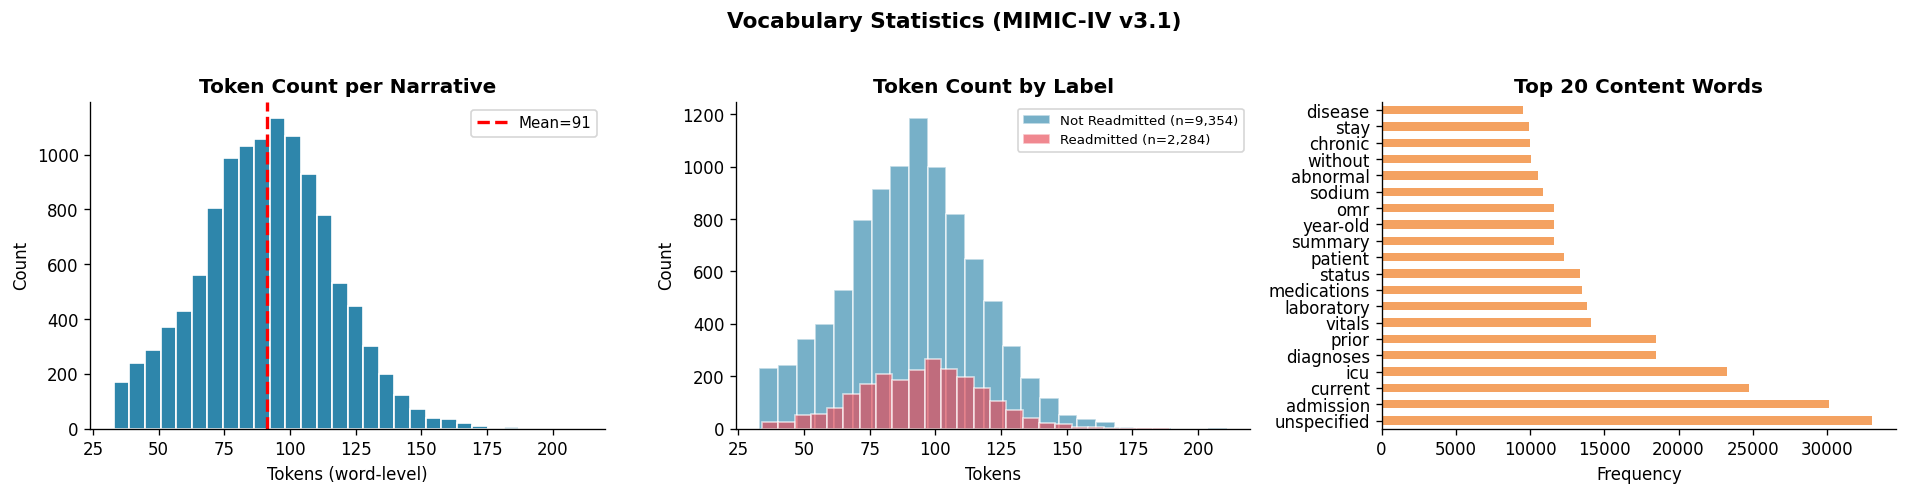

In [4]:
# Plot Setup
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Token Count Distribution
axes[0].hist(
    dataset['token_count'],
    bins=30,
    color=PALETTE[0],
    edgecolor='white'
)

axes[0].axvline(
    dataset['token_count'].mean(),
    color='red',
    linestyle='--',
    lw=2,
    label=f'Mean={dataset["token_count"].mean():.0f}'
)

axes[0].set_title('Token Count per Narrative', fontweight='bold')
axes[0].set_xlabel('Tokens (word-level)')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)


# Token Count by Label
for label, color in [(0, PALETTE[0]), (1, PALETTE[1])]:
    sub = dataset[dataset['readmission_30d'] == label]['token_count']

    axes[1].hist(
        sub,
        bins=25,
        alpha=0.65,
        color=color,
        edgecolor='white',
        label=f'{"Readmitted" if label else "Not Readmitted"} (n={len(sub):,})'
    )

axes[1].set_title('Token Count by Label', fontweight='bold')
axes[1].set_xlabel('Tokens')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=8)

# Top Content Words
top20 = pd.Series(dict(vocab_content.most_common(20)))

top20.sort_values()[::-1].plot(
    kind='barh',
    ax=axes[2],
    color=PALETTE[2]
)

axes[2].set_title('Top 20 Content Words', fontweight='bold')
axes[2].set_xlabel('Frequency')


# Save and Display
plt.suptitle(
    'Vocabulary Statistics (MIMIC-IV v3.1)',
    fontsize=13,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    f'{FEATURE_ANALYSIS_PLT}/feat_01_vocabulary_stats.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Zipf's Law Analysis

This section examines the frequency distribution of words in the corpus.

- Ranks tokens by frequency
- Plots:
  - Top 500 terms on a linear scale
  - Full vocabulary on a log-log scale
- Evaluates adherence to Zipf's law

This helps characterise the statistical structure of clinical language in the dataset.

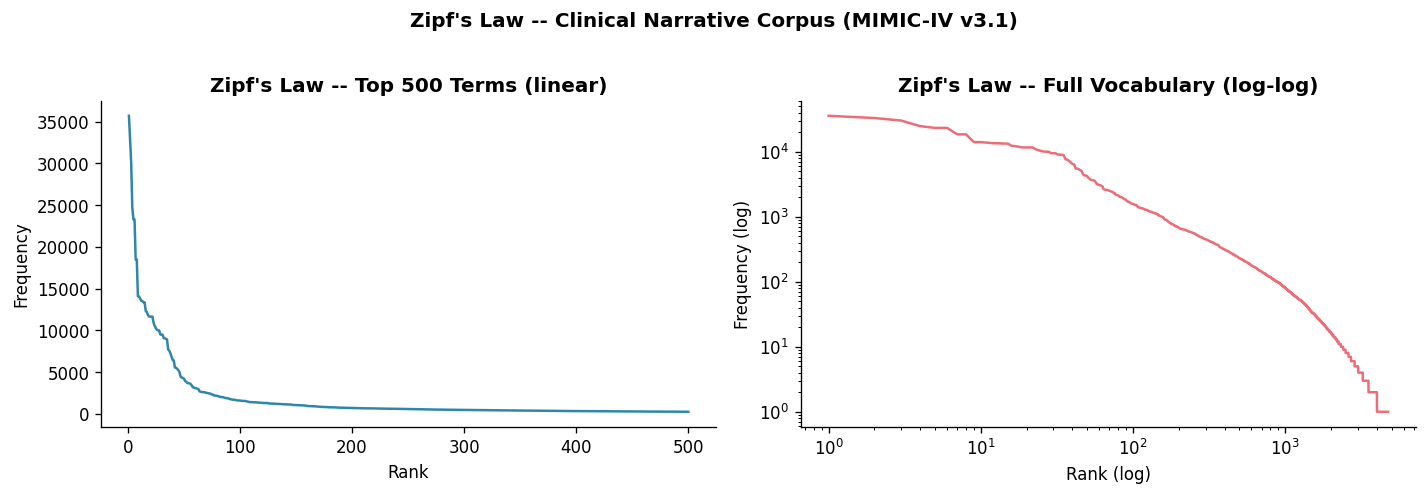

In [5]:
# Frequency and Rank
freqs = sorted(vocab_all.values(), reverse=True)
ranks = np.arange(1, len(freqs) + 1)


# Plot Setup
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear Scale (Top Terms)
axes[0].plot(
    ranks[:500],
    freqs[:500],
    color=PALETTE[0],
    lw=1.5
)

axes[0].set_title("Zipf's Law -- Top 500 Terms (linear)", fontweight='bold')
axes[0].set_xlabel('Rank')
axes[0].set_ylabel('Frequency')

# Log-Log Scale (Full Vocabulary)
axes[1].loglog(
    ranks,
    freqs,
    color=PALETTE[1],
    lw=1.5,
    alpha=0.8
)

axes[1].set_title("Zipf's Law -- Full Vocabulary (log-log)", fontweight='bold')
axes[1].set_xlabel('Rank (log)')
axes[1].set_ylabel('Frequency (log)')

# Save and Display
plt.suptitle(
    "Zipf's Law -- Clinical Narrative Corpus (MIMIC-IV v3.1)",
    fontsize=12,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    f'{FEATURE_ANALYSIS_PLT}/feat_02_zipf_law.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Tokeniser Comparison and Subword Length Analysis

This section evaluates subword tokenisation behaviour across transformer models.

- Compares token counts for selected clinical terms
- Highlights efficiency of domain-specific tokenisers
- Samples narratives to analyse token length distributions
- Computes coverage for common sequence lengths (128, 256, 512)
- Visualises token length distributions across models

This analysis informs selection of an appropriate `max_length` for modelling.


Term                                          DistilBERT    PubMedBERT     BioBERT
------------------------------------------------------------------------------------
myocardial infarction                                  6             2           7 <- best
percutaneous coronary intervention                     6             3           7 <- best
metoprolol tartrate                                    7             5           7 <- best
hypertensive heart disease                             5             3           5 <- best
body mass index                                        3             3           3
estimated glomerular filtration rate                   9             4           8 <- best
electrocardiogram                                      4             1           4 <- best
hyperlipidaemia                                        4             4           5

-> Domain-specific tokenisers encode clinical terms in fewer tokens.
   OMR terms (BMI, eGFR) are also more efficientl

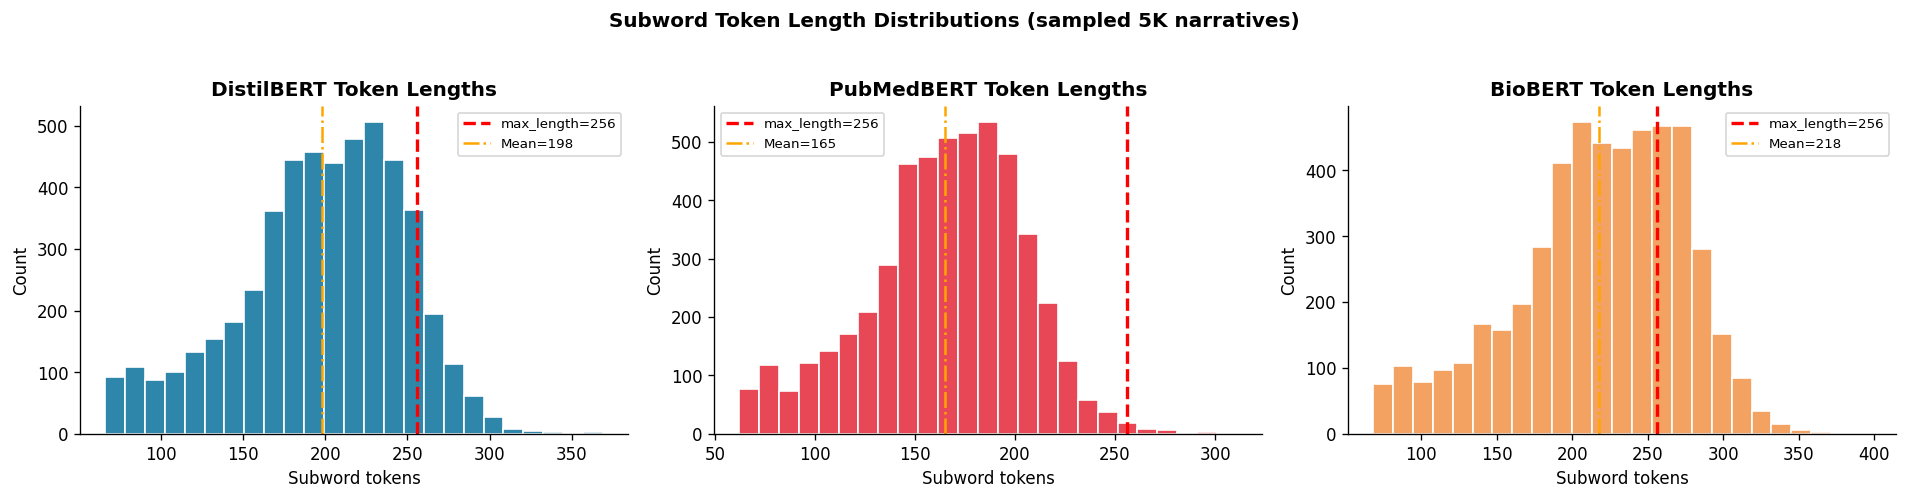

In [6]:
# Tokeniser Loading
tok_db = AutoTokenizer.from_pretrained(DISTILBERT_MODEL_ID)
tok_pm = AutoTokenizer.from_pretrained(PUBMEDBERT_MODEL_ID)
tok_bb = AutoTokenizer.from_pretrained(BIOBERT_MODEL_ID)


# Clinical Terms (including OMR terms)
clinical_terms = [
    'myocardial infarction',
    'percutaneous coronary intervention',
    'metoprolol tartrate',
    'hypertensive heart disease',
    'body mass index',
    'estimated glomerular filtration rate',
    'electrocardiogram',
    'hyperlipidaemia',
]


# Token Length Comparison
print(f'\n{"Term":<42}  {"DistilBERT":>12}  {"PubMedBERT":>12}  {"BioBERT":>10}')
print('-' * 84)

for term in clinical_terms:
    n_db = len(tok_db.tokenize(term))
    n_pm = len(tok_pm.tokenize(term))
    n_bb = len(tok_bb.tokenize(term))

    best = min(n_db, n_pm, n_bb)
    flag = ' <- best' if n_pm == best and n_pm < n_db else ''

    print(f'{term:<42}  {n_db:>12}  {n_pm:>12}  {n_bb:>10}{flag}')


# Summary
print('\n-> Domain-specific tokenisers encode clinical terms in fewer tokens.')
print('   OMR terms (BMI, eGFR) are also more efficiently encoded by PubMedBERT.')


# Sample Narratives 
sample_texts = dataset['narrative'].sample(
    min(5000, len(dataset)),
    random_state=42
).tolist()

print(f'Computing subword lengths on {len(sample_texts):,} sampled narratives...')

# Token Length Computation
len_db = [len(tok_db.tokenize(t)) for t in sample_texts]
len_pm = [len(tok_pm.tokenize(t)) for t in sample_texts]
len_bb = [len(tok_bb.tokenize(t)) for t in sample_texts]

# Summary Statistics
print(f'\n{"Tokeniser":<15} {"Mean":>7} {"Std":>6} {"<=128":>7} {"<=256":>7} {"<=512":>7}')
print('-' * 55)

for name, lens in [
    ('DistilBERT', len_db),
    ('PubMedBERT', len_pm),
    ('BioBERT',    len_bb)
]:
    a = np.array(lens)

    print(
        f'{name:<15} {a.mean():>7.1f} {a.std():>6.1f} '
        f'{(a<=128).mean()*100:>6.1f}% '
        f'{(a<=256).mean()*100:>6.1f}% '
        f'{(a<=512).mean()*100:>6.1f}%'
    )

print('\n-> max_length=256 covers >=95% of narratives across all tokenisers.')


# Plot Setup
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Token Length Distributions
for ax, (name, lens, color) in zip(axes, [
    ('DistilBERT', len_db, PALETTE[0]),
    ('PubMedBERT', len_pm, PALETTE[1]),
    ('BioBERT',    len_bb, PALETTE[2])
]):
    ax.hist(
        lens,
        bins=25,
        color=color,
        edgecolor='white'
    )

    ax.axvline(256, color='red', linestyle='--', lw=2, label='max_length=256')

    ax.axvline(
        np.mean(lens),
        color='orange',
        linestyle='-.',
        lw=1.5,
        label=f'Mean={np.mean(lens):.0f}'
    )

    ax.set_title(f'{name} Token Lengths', fontweight='bold')
    ax.set_xlabel('Subword tokens')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)


# Save and Display
plt.suptitle(
    'Subword Token Length Distributions (sampled 5K narratives)',
    fontsize=12,
    fontweight='bold',
    y=1.03
)

plt.tight_layout()

plt.savefig(
    f'{FEATURE_ANALYSIS_PLT}/feat_03_bert_token_lengths.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## TF-IDF Feature Analysis

This section identifies discriminative textual features using TF-IDF.

- Samples narratives for computational efficiency
- Applies TF-IDF vectorisation with unigrams and bigrams
- Computes class-wise mean TF-IDF scores
- Identifies features most associated with:
  - Readmitted patients
  - Non-readmitted patients
- Visualises top discriminative terms

This provides insight into language patterns linked to readmission risk.

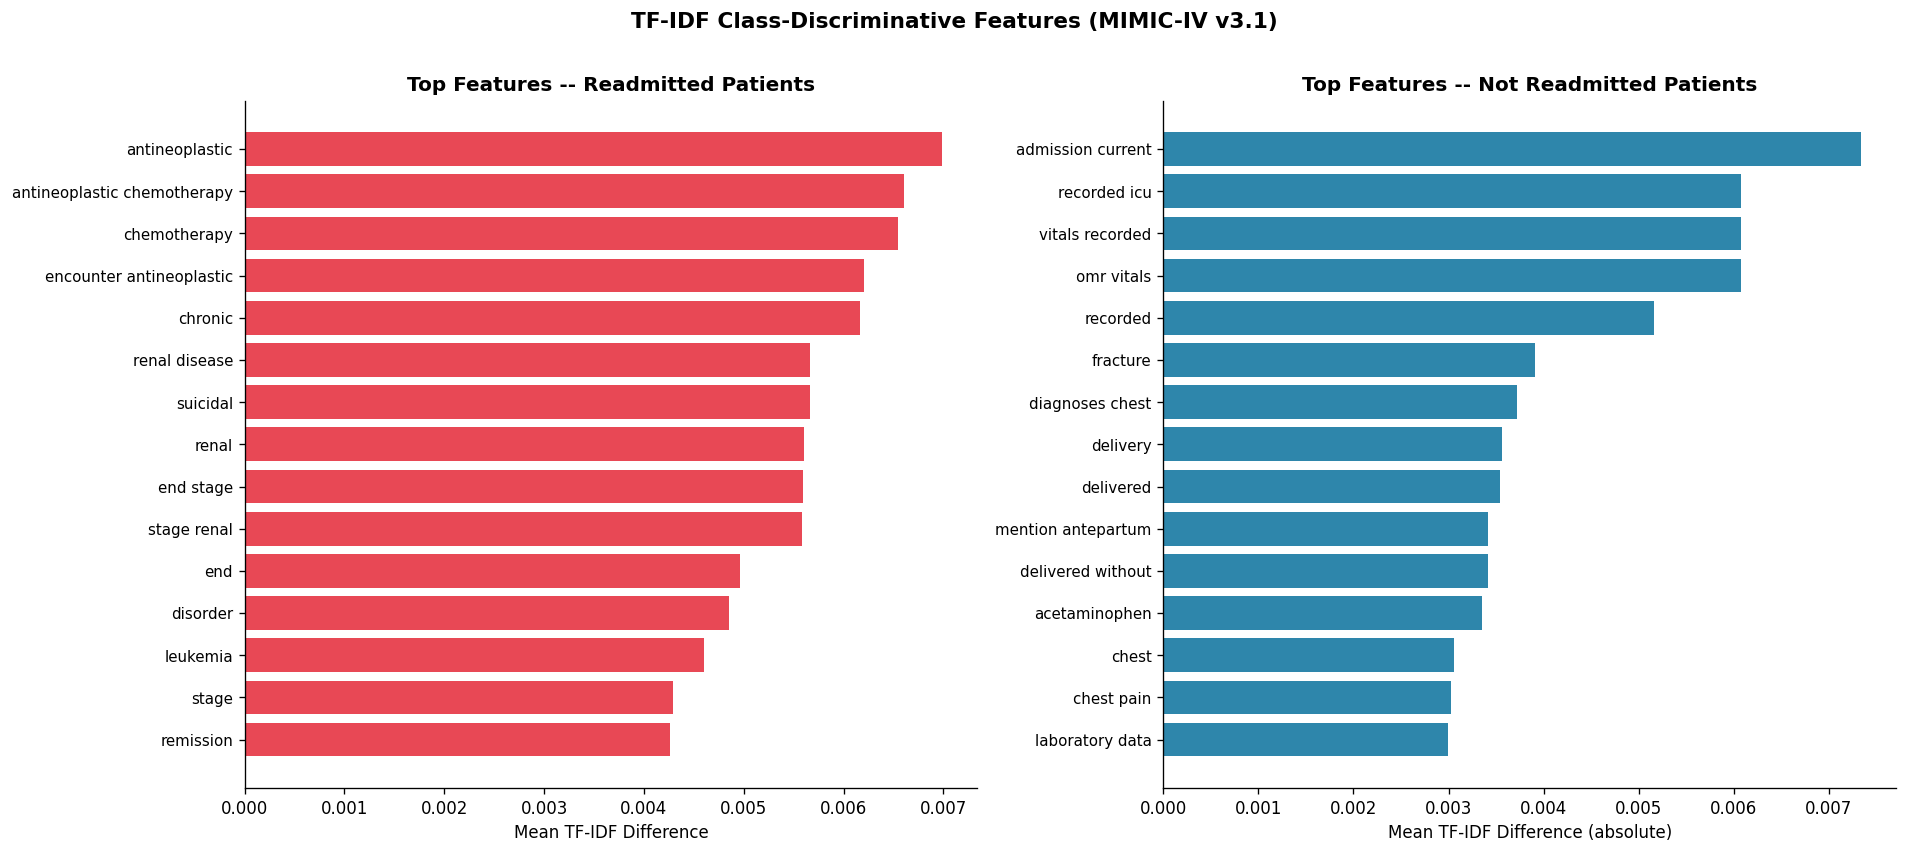

In [7]:
# Sample Texts for TF-IDF
sample_idx = np.random.RandomState(42).choice(
    len(all_texts),
    size=min(50000, len(all_texts)),
    replace=False
)

sample_texts_tfidf = [all_texts[i] for i in sample_idx]
sample_y = y[sample_idx]

# TF-IDF Vectorisation
tfidf_vec = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    stop_words=list(STOP),
    sublinear_tf=True,
    min_df=3
)

X_tfidf = tfidf_vec.fit_transform(sample_texts_tfidf)
feat_names = np.array(tfidf_vec.get_feature_names_out())

# Class-Wise Mean TF-IDF
mean_pos = X_tfidf[sample_y == 1].mean(axis=0).A1
mean_neg = X_tfidf[sample_y == 0].mean(axis=0).A1

diff = mean_pos - mean_neg

# Top Disciminative Features
top_pos = diff.argsort()[-18:][::-1]
top_neg = diff.argsort()[:18]


# Plot Setup
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Readmitted Features
axes[0].barh(
    range(15),
    diff[top_pos[:15]][::-1],
    color=PALETTE[1]
)

axes[0].set_yticks(range(15))
axes[0].set_yticklabels(feat_names[top_pos[:15]][::-1], fontsize=9)
axes[0].set_title('Top Features -- Readmitted Patients', fontweight='bold')
axes[0].set_xlabel('Mean TF-IDF Difference')

# Not Readmitted Features
axes[1].barh(
    range(15),
    abs(diff[top_neg[:15]][::-1]),
    color=PALETTE[0]
)

axes[1].set_yticks(range(15))
axes[1].set_yticklabels(feat_names[top_neg[:15]][::-1], fontsize=9)
axes[1].set_title('Top Features -- Not Readmitted Patients', fontweight='bold')
axes[1].set_xlabel('Mean TF-IDF Difference (absolute)')

# Save and Display
plt.suptitle(
    'TF-IDF Class-Discriminative Features (MIMIC-IV v3.1)',
    fontsize=13,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()

plt.savefig(
    f'{FEATURE_ANALYSIS_PLT}/feat_04_tfidf_class_features.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## N-gram Analysis

This section analyses bigram frequency patterns across classes.

- Extracts top bigrams using count-based vectorisation
- Computes frequencies separately for:
  - Readmitted patients
  - Non-readmitted patients
- Visualises most frequent bigrams per class

This highlights common phrase-level patterns associated with readmission outcomes.

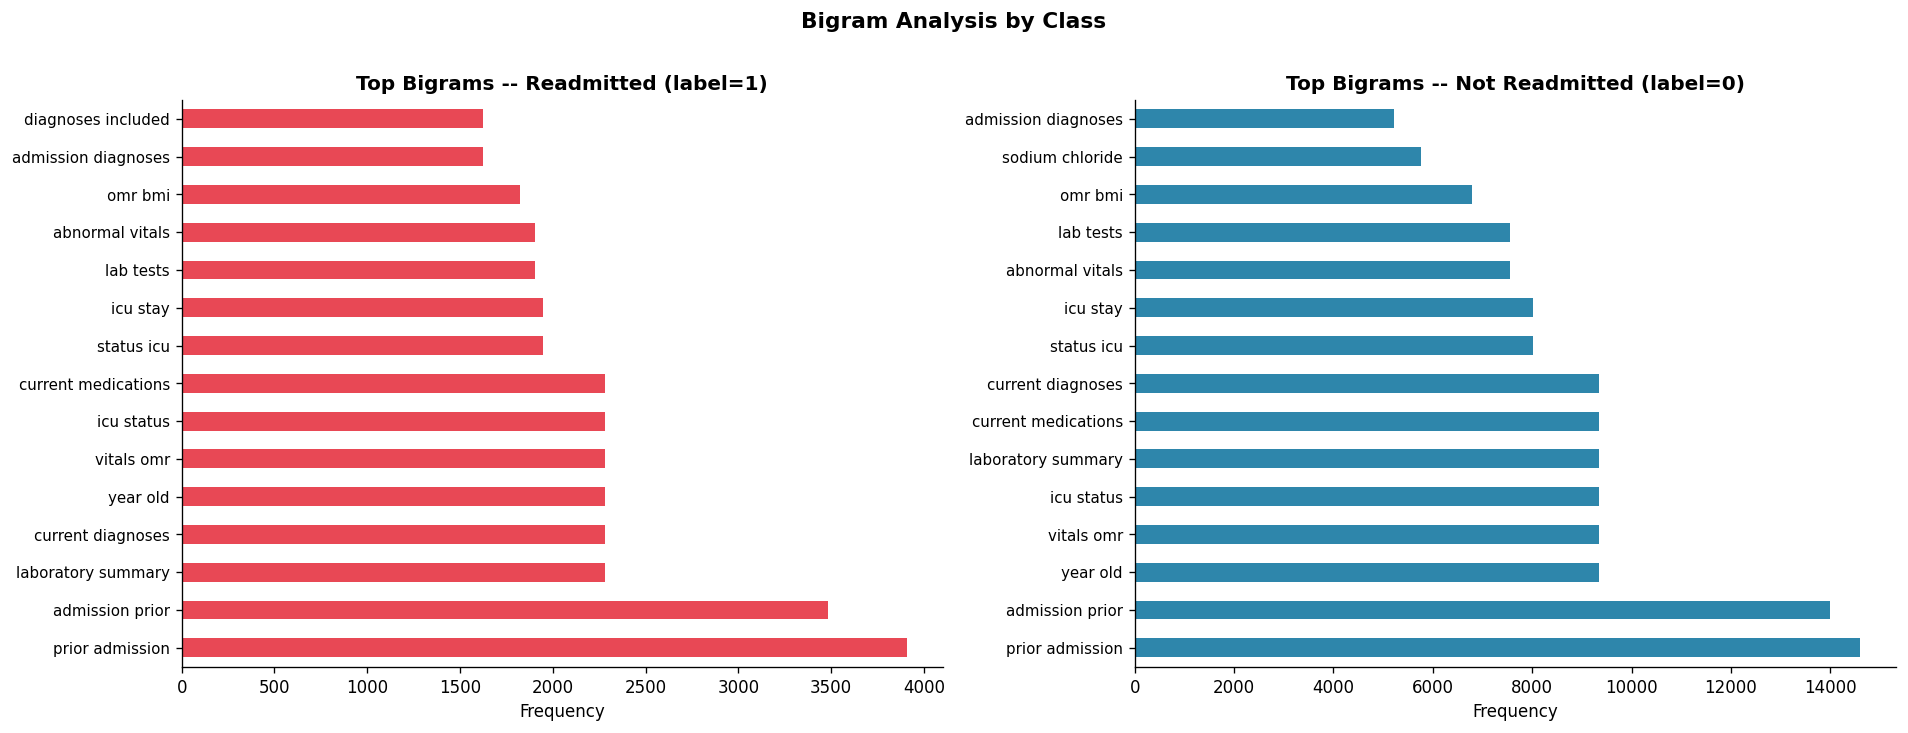

In [8]:
# Function to get Top N-Grams
def top_ngrams(texts, n, k=15):
    sample = texts[:min(20000, len(texts))]

    vec = CountVectorizer(
        ngram_range=(n, n),
        stop_words=list(STOP),
        max_features=5000
    )

    X = vec.fit_transform(sample)

    return pd.Series(
        X.sum(axis=0).A1,
        index=vec.get_feature_names_out()
    ).sort_values(ascending=False).head(k)

# Compute Bigrams by Class
bi_pos = top_ngrams(pos_texts, n=2)
bi_neg = top_ngrams(neg_texts, n=2)

# Plot Setup
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Readmitted Bigrams
bi_pos.sort_values()[::-1].plot(
    kind='barh',
    ax=axes[0],
    color=PALETTE[1]
)

axes[0].set_title('Top Bigrams -- Readmitted (label=1)', fontweight='bold')
axes[0].set_xlabel('Frequency')
axes[0].tick_params(axis='y', labelsize=9)

# Not Readmitted Bigrams
bi_neg.sort_values()[::-1].plot(
    kind='barh',
    ax=axes[1],
    color=PALETTE[0]
)

axes[1].set_title('Top Bigrams -- Not Readmitted (label=0)', fontweight='bold')
axes[1].set_xlabel('Frequency')
axes[1].tick_params(axis='y', labelsize=9)

# Save and Display
plt.suptitle(
    'Bigram Analysis by Class',
    fontsize=13,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()

plt.savefig(
    f'{FEATURE_ANALYSIS_PLT}/feat_05_ngram_analysis.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Corpus Summary Statistics

This section reports key corpus-level statistics.

- Dataset size and vocabulary metrics
- Token-level and subword-level statistics
- Class distribution
- Dataset metadata and preprocessing indicators

These summaries provide a final validation of the processed dataset.

In [9]:
# Corpus Statistics Summary
print('=' * 64)
print('  CORPUS STATISTICS -- MIMIC-IV v3.1')
print('=' * 64)

# Dataset Size and Vocabulary
print(f'  Total narratives             : {len(dataset):,}')
print(f'  Vocabulary (all tokens)      : {len(vocab_all):,}')
print(f'  Vocabulary (content tokens)  : {len(vocab_content):,}')
print(f'  Type-Token Ratio (TTR)       : {len(vocab_all)/len(all_tokens):.4f}')

# Token Statistics
print(
    f'  Avg word tokens / narrative  : {dataset["token_count"].mean():.1f} '
    f'+/- {dataset["token_count"].std():.1f}'
)

# Subword Token Statistics
print(f'  Avg DistilBERT tokens        : {np.mean(len_db):.1f} +/- {np.std(len_db):.1f}')
print(f'  Avg PubMedBERT tokens        : {np.mean(len_pm):.1f} +/- {np.std(len_pm):.1f}')
print(f'  Avg BioBERT tokens           : {np.mean(len_bb):.1f} +/- {np.std(len_bb):.1f}')

# Class Distribution
print(
    f'  Positive class (readmitted)  : {dataset["readmission_30d"].sum():,} '
    f'({dataset["readmission_30d"].mean()*100:.1f}%)'
)

# Dataset Metadata
print(f'  Unique patients              : {dataset["subject_id"].nunique():,}')
print(f'  OMR vitals in narratives     : YES (BMI, weight from omr table)')
print(f'  dod correction applied       : YES')

print('=' * 64)

  CORPUS STATISTICS -- MIMIC-IV v3.1
  Total narratives             : 11,638
  Vocabulary (all tokens)      : 4,744
  Vocabulary (content tokens)  : 4,690
  Type-Token Ratio (TTR)       : 0.0045
  Avg word tokens / narrative  : 91.4 +/- 24.9
  Avg DistilBERT tokens        : 197.9 +/- 50.5
  Avg PubMedBERT tokens        : 165.1 +/- 39.2
  Avg BioBERT tokens           : 217.6 +/- 55.9
  Positive class (readmitted)  : 2,284 (19.6%)
  Unique patients              : 4,777
  OMR vitals in narratives     : YES (BMI, weight from omr table)
  dod correction applied       : YES
